# RSNN on FI-2010 Financial Time Series

**Goal**: Apply the RSNN architecture (validated on SHD and ECG) to financial limit order book data

**Results carried forward**:
| Dataset | Architecture | Best Accuracy |
|---|---|---|
| SHD (audio) | Best Effort RSNN | 78.7% |
| PTB-XL (ECG) | RSNN + Delta Modulation | 63.1% |

**FI-2010 Dataset** (Ntakaris et al., 2018):
- 10 days of Nokia stock LOB from NASDAQ Nordic (June 2010)
- 40 features: 10 levels × (ask_price, ask_vol, bid_price, bid_vol)
- Task: Predict mid-price direction (Up / Stationary / Down) — 3 classes
- 5 prediction horizons: k = 10, 20, 30, 50, 100 events
- Standard protocol: Days 1-7 train, Day 8 val, Days 8-9 test (DeepLOB convention)

**Experiments**:
1. RSNN + Direct Input (baseline)
2. RSNN + Delta Modulation (best from ECG phase)
3. LSTM baseline
4. 1D-CNN baseline
5. Temporal analysis on best SNN model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

Device: cuda
GPU: Tesla P100-PCIE-16GB


## 1. Load FI-2010 Dataset

**Option A (Kaggle)**: Add dataset "fi-2010" by ulfricirons → Add Input  
**Option B (Download)**: Download from DeepLOB GitHub (code below handles both)

The data files are:
- `Train_Dst_NoAuction_DecPre_CF_7.txt` — Training data (days 1-7)
- `Test_Dst_NoAuction_DecPre_CF_7.txt` — Test anchored at day 7
- `Test_Dst_NoAuction_DecPre_CF_8.txt` — Test anchored at day 8  
- `Test_Dst_NoAuction_DecPre_CF_9.txt` — Test anchored at day 9

Format: Each file has 149 rows × ~N columns. Rows 1-40 = LOB features, rows 41-144 = derived features (unused), rows 145-149 = labels at 5 horizons.

In [2]:
import glob
import subprocess

# Download FI-2010 from DeepLOB repository
print("Downloading FI-2010 from DeepLOB repository...")
subprocess.run(['wget', '-q', 
    'https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip',
    '-O', '/kaggle/working/data.zip'], check=True)
subprocess.run(['unzip', '-q', '-o', '/kaggle/working/data.zip', '-d', '/kaggle/working/'], check=True)
DATA_DIR = '/kaggle/working'
print("Downloaded and extracted.")

print(f"Data directory: {DATA_DIR}")
train_files = sorted(glob.glob(os.path.join(DATA_DIR, "Train_Dst_NoAuction*.txt")))
test_files = sorted(glob.glob(os.path.join(DATA_DIR, "Test_Dst_NoAuction*.txt")))
print(f"Train files: {[os.path.basename(f) for f in train_files]}")
print(f"Test files: {[os.path.basename(f) for f in test_files]}")

Downloaded and extracted.
Data directory: /kaggle/working
Train files: ['Train_Dst_NoAuction_DecPre_CF_7.txt']
Test files: ['Test_Dst_NoAuction_DecPre_CF_7.txt', 'Test_Dst_NoAuction_DecPre_CF_8.txt', 'Test_Dst_NoAuction_DecPre_CF_9.txt']


## 2. Data Preprocessing (Following DeepLOB Protocol)

In [3]:
def prepare_x(data):
    """Extract first 40 features (LOB levels) from raw data.
    Data format: rows = features, columns = time events.
    Returns: (n_events, 40) array."""
    # Rows 0-39 are the 40 LOB features
    df = data[:40, :].T
    return df.astype(np.float32)

def get_label(data):
    """Extract labels (rows 144-148, the 5 prediction horizons).
    Returns: (n_events, 5) array with labels 0,1,2 (was 1,2,3)."""
    labels = data[-5:, :].T
    # Original labels: 1=down, 2=stationary, 3=up → remap to 0,1,2
    labels = labels.astype(int) - 1
    return labels

def data_classification(X, Y, T=100):
    """Create sliding window sequences of length T.
    Input X: (n_events, 40), Y: (n_events, 5)
    Output: X_seq: (n_samples, T, 40), Y_seq: (n_samples, 5)"""
    N = X.shape[0]
    samples = N - T + 1
    X_seq = np.zeros((samples, T, X.shape[1]), dtype=np.float32)
    for i in range(samples):
        X_seq[i] = X[i:i+T]
    Y_seq = Y[T-1:]  # Label corresponds to the last timestep in window
    return X_seq, Y_seq

# Load training data (days 1-7)
dec_train = np.loadtxt(os.path.join(DATA_DIR, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
print(f"Raw train shape: {dec_train.shape}")

# Load test data (day 8, 9, 10 combined — standard uses CF_7, CF_8, CF_9)
test_data_list = []
for tf in test_files:
    test_data_list.append(np.loadtxt(tf))
dec_test = np.hstack(test_data_list) if len(test_data_list) > 1 else test_data_list[0]
print(f"Raw test shape: {dec_test.shape}")

# Extract features and labels
train_lob = prepare_x(dec_train)
train_label = get_label(dec_train)
test_lob = prepare_x(dec_test)
test_label = get_label(dec_test)

print(f"Train LOB: {train_lob.shape}, Labels: {train_label.shape}")
print(f"Test LOB: {test_lob.shape}, Labels: {test_label.shape}")

Raw train shape: (149, 254750)
Raw test shape: (149, 139587)
Train LOB: (254750, 40), Labels: (254750, 5)
Test LOB: (139587, 40), Labels: (139587, 5)


In [4]:
# Create sequences with window T=100 (DeepLOB standard)
T = 100  # Lookback window: 100 events

X_train_seq, y_train_seq = data_classification(train_lob, train_label, T=T)
X_test_seq, y_test_seq = data_classification(test_lob, test_label, T=T)

# Use prediction horizon k=5 (index 3, corresponds to k=50 events)
# This is the most commonly reported horizon
HORIZON = 3  # Index: 0=k10, 1=k20, 2=k30, 3=k50, 4=k100
HORIZON_NAMES = ['k=10', 'k=20', 'k=30', 'k=50', 'k=100']

y_train = y_train_seq[:, HORIZON]
y_test = y_test_seq[:, HORIZON]

# Split validation from training (last 20%)
val_split = int(len(X_train_seq) * 0.8)
X_val_seq = X_train_seq[val_split:]
y_val = y_train[val_split:]
X_train_seq = X_train_seq[:val_split]
y_train = y_train[:val_split]

print(f"Horizon: {HORIZON_NAMES[HORIZON]}")
print(f"Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")
print(f"\nLabel distribution (train):")
for i, name in enumerate(['Down', 'Stationary', 'Up']):
    n = (y_train == i).sum()
    print(f"  {name}: {n} ({n/len(y_train)*100:.1f}%)")

Horizon: k=50
Train: (203720, 100, 40) | Val: (50931, 100, 40) | Test: (139488, 100, 40)

Label distribution (train):
  Down: 71425 (35.1%)
  Stationary: 61824 (30.3%)
  Up: 70471 (34.6%)


## 3. Visualize LOB Data

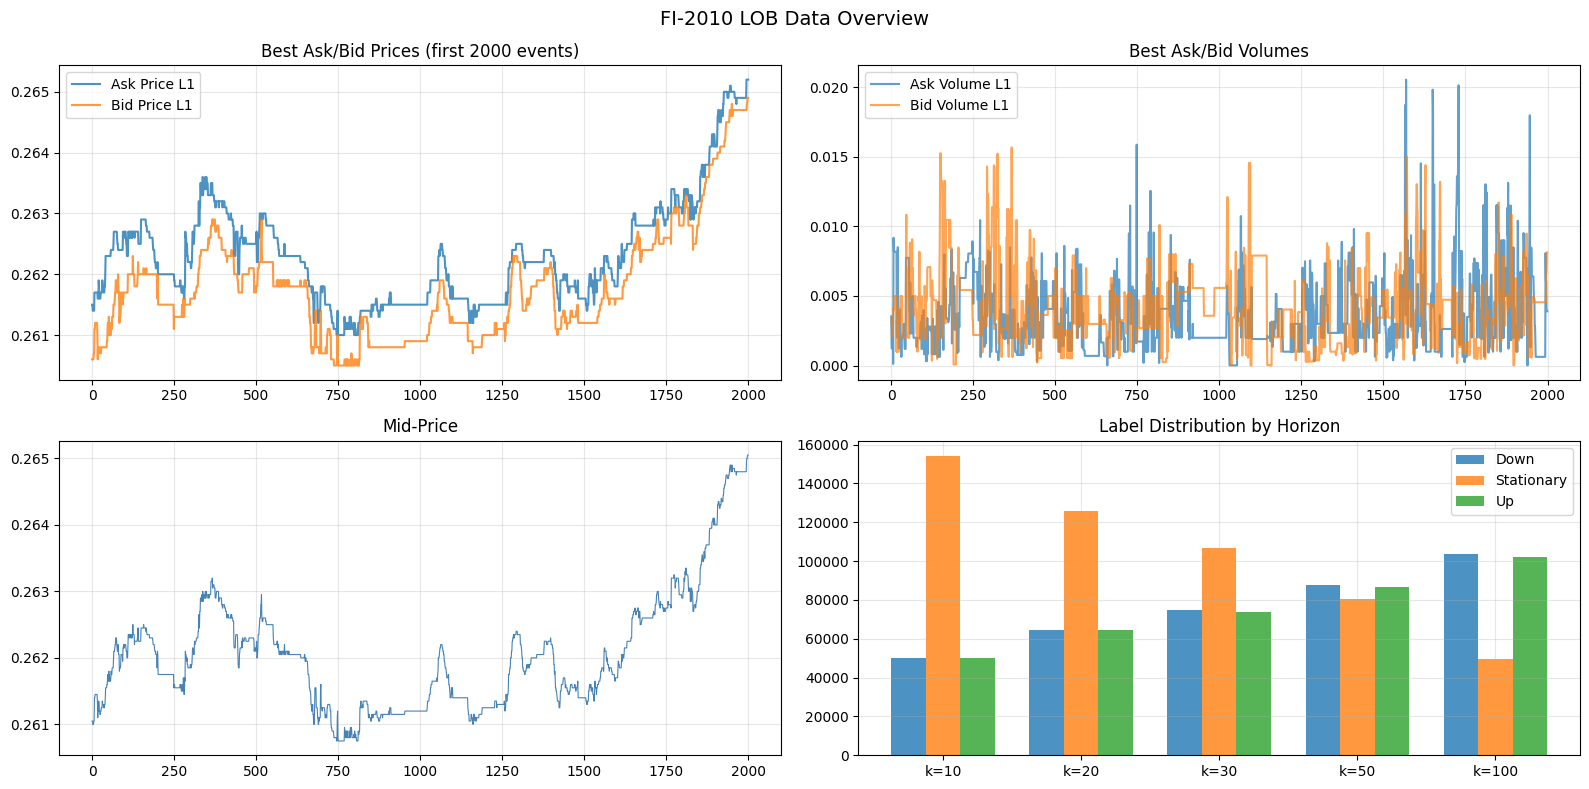

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Best ask and bid prices over time
sample_data = train_lob[:2000]
t = np.arange(len(sample_data))
axes[0,0].plot(t, sample_data[:, 0], label='Ask Price L1', alpha=0.8)
axes[0,0].plot(t, sample_data[:, 2], label='Bid Price L1', alpha=0.8)
axes[0,0].set_title('Best Ask/Bid Prices (first 2000 events)')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Volume at L1
axes[0,1].plot(t, sample_data[:, 1], label='Ask Volume L1', alpha=0.7)
axes[0,1].plot(t, sample_data[:, 3], label='Bid Volume L1', alpha=0.7)
axes[0,1].set_title('Best Ask/Bid Volumes')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Mid-price
mid_price = (sample_data[:, 0] + sample_data[:, 2]) / 2
axes[1,0].plot(t, mid_price, color='steelblue', linewidth=0.8)
axes[1,0].set_title('Mid-Price'); axes[1,0].grid(True, alpha=0.3)

# Label distribution across all horizons
labels_all = get_label(dec_train)
horizon_counts = []
for h in range(5):
    counts = [(labels_all[:, h] == i).sum() for i in range(3)]
    horizon_counts.append(counts)
horizon_counts = np.array(horizon_counts)
x = np.arange(5)
w = 0.25
axes[1,1].bar(x - w, horizon_counts[:, 0], w, label='Down', alpha=0.8)
axes[1,1].bar(x, horizon_counts[:, 1], w, label='Stationary', alpha=0.8)
axes[1,1].bar(x + w, horizon_counts[:, 2], w, label='Up', alpha=0.8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(HORIZON_NAMES)
axes[1,1].set_title('Label Distribution by Horizon')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('FI-2010 LOB Data Overview', fontsize=14)
plt.tight_layout(); plt.show()

## 4. Spike Encoding & Dataset

In [6]:
class SpikeEncoder:
    @staticmethod
    def direct(signal):
        return signal
    
    @staticmethod
    def delta_modulation(signal, threshold=0.1):
        T, C = signal.shape
        spikes = np.zeros_like(signal)
        reference = signal[0].copy()
        for t in range(1, T):
            diff = signal[t] - reference
            up = diff > threshold
            down = diff < -threshold
            spikes[t, up] = 1.0
            spikes[t, down] = -1.0
            reference[up] = signal[t, up]
            reference[down] = signal[t, down]
        return spikes


class LOBDataset(Dataset):
    def __init__(self, X, y, encoding='direct', **enc_kwargs):
        self.X = X  # [N, T, 40]
        self.y = torch.tensor(y, dtype=torch.long)
        self.encoding = encoding
        self.enc_kwargs = enc_kwargs
        
        sample = self._encode(X[0])
        self.input_size = sample.shape[1]
    
    def _encode(self, seq):
        if self.encoding == 'direct':
            return SpikeEncoder.direct(seq)
        elif self.encoding == 'delta':
            return SpikeEncoder.delta_modulation(seq, **self.enc_kwargs)
        return seq
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        encoded = self._encode(self.X[idx])
        return torch.tensor(encoded, dtype=torch.float32), self.y[idx]


def create_lob_loaders(X_train, y_train, X_val, y_val, X_test, y_test,
                       encoding='direct', batch_size=256, **kwargs):
    train_ds = LOBDataset(X_train, y_train, encoding, **kwargs)
    val_ds = LOBDataset(X_val, y_val, encoding, **kwargs)
    test_ds = LOBDataset(X_test, y_test, encoding, **kwargs)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"Encoding: {encoding} | Input: [{T}, {train_ds.input_size}] | 3 classes")
    return train_loader, val_loader, test_loader, train_ds.input_size

# Direct input loaders
train_ld, val_ld, test_ld, inp_sz = create_lob_loaders(
    X_train_seq, y_train, X_val_seq, y_val, X_test_seq, y_test, encoding='direct', batch_size=256)

# Delta modulation loaders
train_ld_dm, val_ld_dm, test_ld_dm, inp_sz_dm = create_lob_loaders(
    X_train_seq, y_train, X_val_seq, y_val, X_test_seq, y_test, 
    encoding='delta', batch_size=256, threshold=0.1)

Encoding: direct | Input: [100, 40] | 3 classes
Encoding: delta | Input: [100, 40] | 3 classes


## 5. SNN Architecture (Same as SHD & ECG)

In [7]:
class SurrogateSpike(torch.autograd.Function):
    beta = 40.0
    @staticmethod
    def forward(ctx, mem, threshold=1.0):
        ctx.save_for_backward(mem)
        ctx.threshold = threshold
        return (mem >= threshold).float()
    @staticmethod
    def backward(ctx, grad_output):
        mem, = ctx.saved_tensors
        v = mem - ctx.threshold
        grad = 1.0 / (1.0 + SurrogateSpike.beta * torch.abs(v)) ** 2
        return grad_output * grad, None

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)


class LIFLayer(nn.Module):
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt
        self.dropout = dropout
        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent:
            self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent:
            nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')

    @property
    def alpha(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))
    @property  
    def beta_decay(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        B, T_steps, _ = x.shape
        alpha, beta = self.alpha, self.beta_decay
        syn = torch.zeros(B, self.hidden_size, device=x.device)
        mem = torch.zeros(B, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(B, self.hidden_size, device=x.device)
        spk_rec, mem_rec = [], []
        for t in range(T_steps):
            syn = alpha * syn + self.W_ff(x[:, t])
            if self.recurrent:
                rec_in = F.dropout(prev_spk, p=self.dropout, training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_in)
            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem)
            spk_rec.append(spk); mem_rec.append(mem)
            prev_spk = spk
        return torch.stack(spk_rec, dim=1), torch.stack(mem_rec, dim=1)


class ReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')
    def forward(self, x):
        B, T_steps, _ = x.shape
        mem = torch.zeros(B, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(T_steps):
            mem = self.beta * mem + (1 - self.beta) * self.fc(x[:, t])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)


class SNN(nn.Module):
    def __init__(self, input_size=40, hidden_size=256, output_size=3,
                 recurrent=True, tau_mem=20.0, tau_syn=10.0, dt=10.0,
                 learnable_tau=True, loss_mode='max_over_time', dropout=0.3):
        super().__init__()
        self.loss_mode = loss_mode
        self.lif = LIFLayer(input_size, hidden_size, recurrent=recurrent,
                            tau_mem_init=tau_mem, tau_syn_init=tau_syn, dt=dt,
                            learnable_tau=learnable_tau, dropout=dropout)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem=tau_mem, dt=dt)

    def forward(self, x):
        spikes, _ = self.lif(x)
        out_mem = self.readout(spikes)
        if self.loss_mode == 'max_over_time':
            output, _ = torch.max(out_mem, dim=1)
        else:
            output = out_mem[:, -1, :]
        return output, [spikes], out_mem

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("SNN architecture loaded")
m = SNN(input_size=40, hidden_size=256, output_size=3)
print(f"RSNN for LOB: {m.count_params():,} params")
del m

SNN architecture loaded
RSNN for LOB: 76,546 params


In [8]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg = torch.tensor(0.0, device=all_spikes[0].device)
    for spk in all_spikes:
        B, T_s, N = spk.shape
        mean_rate = spk.sum(dim=1) / T_s
        reg += s_l / (B * N) * (F.relu(theta_l - mean_rate) ** 2).sum()
        pop_count = spk.sum(dim=(1, 2)) / N
        reg += s_u / B * (F.relu(pop_count - theta_u) ** 2).sum()
    return reg


class Trainer:
    def __init__(self, model, train_ld, val_ld, test_ld, lr=1e-3, device='cuda'):
        self.model = model.to(device)
        self.train_ld, self.val_ld, self.test_ld = train_ld, val_ld, test_ld
        self.device = device
        self.optimizer = torch.optim.Adamax(model.parameters(), lr=lr)
        
        # Class weights for imbalanced labels
        all_labels = torch.cat([y for _, y in train_ld])
        counts = torch.bincount(all_labels, minlength=3).float()
        weights = (1.0 / counts) / (1.0 / counts).sum() * 3
        self.criterion = nn.CrossEntropyLoss(weight=weights.to(device))
        
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
                        'spike_rates': [], 'epoch_time': []}

    def _run_epoch(self, loader, train=False):
        self.model.train() if train else self.model.eval()
        total_loss, correct, total, spk_rates = 0, 0, 0, []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                logits, all_spk, _ = self.model(x)
                cls_loss = self.criterion(logits, y)
                if train:
                    loss = cls_loss + spike_regularization(all_spk)
                    self.optimizer.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total_loss += cls_loss.item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                total += x.size(0)
                spk_rates.extend([s.detach().mean().item() for s in all_spk])
        return total_loss/total, correct/total, np.mean(spk_rates)

    def train(self, n_epochs=80, patience=20):
        best_val, best_state, no_improve = 0, None, 0
        for ep in range(n_epochs):
            t0 = time.time()
            tr_l, tr_a, sr = self._run_epoch(self.train_ld, train=True)
            va_l, va_a, _ = self._run_epoch(self.val_ld)
            dt_ep = time.time() - t0
            self.history['train_loss'].append(tr_l); self.history['train_acc'].append(tr_a)
            self.history['val_loss'].append(va_l); self.history['val_acc'].append(va_a)
            self.history['spike_rates'].append(sr); self.history['epoch_time'].append(dt_ep)
            if va_a > best_val + 0.001:
                best_val = va_a
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
            if ep % 5 == 0 or no_improve >= patience:
                print(f"Ep {ep:3d} | Tr: {tr_a:.4f} | Va: {va_a:.4f} | Spk: {sr:.4f} | Best: {best_val:.4f} | {dt_ep:.1f}s")
            if no_improve >= patience:
                print(f"Early stop at epoch {ep}"); break
        if best_state:
            self.model.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})
        _, te_a, _ = self._run_epoch(self.test_ld)
        self.history['test_acc'] = te_a
        print(f"\nBest val: {best_val*100:.2f}% | Test: {te_a*100:.2f}% | Time: {sum(self.history['epoch_time'])/60:.1f}min")
        return te_a

    def plot(self, title=""):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        axes[0].plot(self.history['train_acc'], label='Train'); axes[0].plot(self.history['val_acc'], label='Val')
        axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        axes[1].plot(self.history['train_loss'], label='Train'); axes[1].plot(self.history['val_loss'], label='Val')
        axes[1].set_title(f'{title} — Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
        axes[2].plot(self.history['spike_rates'], color='green')
        axes[2].set_title(f'{title} — Spike Rate'); axes[2].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

print("Trainer ready")

Trainer ready


## 6. Experiment 1: RSNN with Direct Input

EXPERIMENT 1: RSNN — Direct Input
Params: 76,546
Ep   0 | Tr: 0.3602 | Va: 0.3700 | Spk: 0.0015 | Best: 0.3700 | 111.6s
Ep   5 | Tr: 0.3662 | Va: 0.3239 | Spk: 0.0084 | Best: 0.3700 | 105.7s
Ep  10 | Tr: 0.3746 | Va: 0.3514 | Spk: 0.0229 | Best: 0.3700 | 105.1s
Ep  15 | Tr: 0.3800 | Va: 0.3414 | Spk: 0.0332 | Best: 0.3700 | 105.4s
Ep  20 | Tr: 0.3822 | Va: 0.3700 | Spk: 0.0471 | Best: 0.3700 | 105.7s
Early stop at epoch 20

Best val: 37.00% | Test: 37.56% | Time: 37.2min


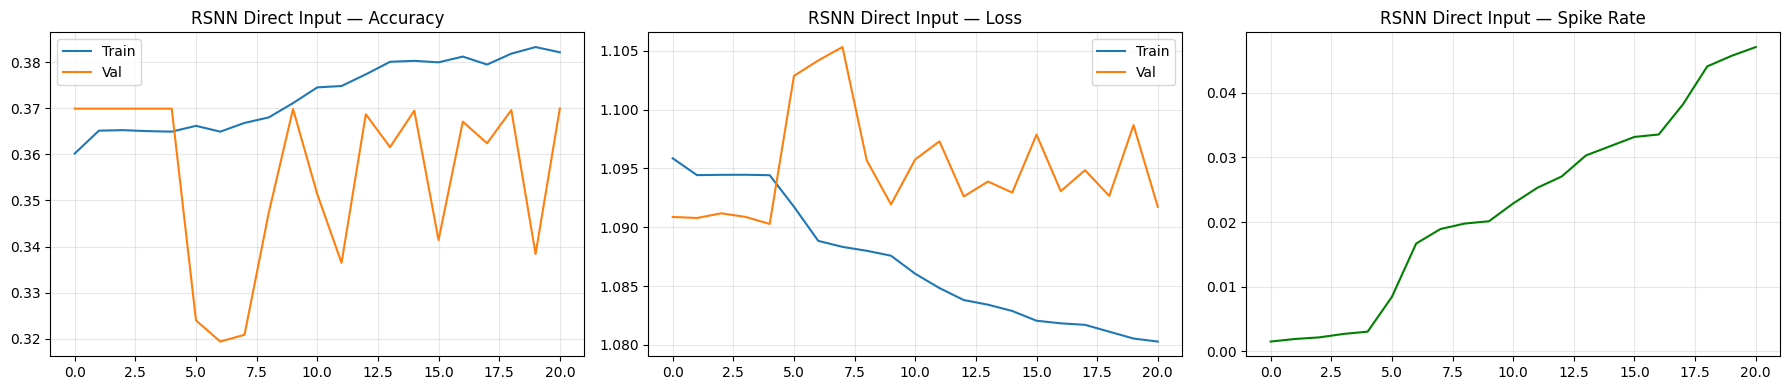

In [9]:
print("=" * 60)
print("EXPERIMENT 1: RSNN — Direct Input")
print("=" * 60)

# dt: FI-2010 events are ~100ms apart (10 events per second approx)
# Use dt=10 (arbitrary units matching SHD convention)
model_direct = SNN(input_size=inp_sz, hidden_size=256, output_size=3,
                   recurrent=True, tau_mem=20.0, tau_syn=10.0, dt=10.0,
                   learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
print(f"Params: {model_direct.count_params():,}")

trainer_direct = Trainer(model_direct, train_ld, val_ld, test_ld, lr=1e-3, device=device)
acc_direct = trainer_direct.train(n_epochs=80, patience=20)
trainer_direct.plot("RSNN Direct Input")

## 7. Experiment 2: RSNN with Delta Modulation 

EXPERIMENT 2: RSNN — Delta Modulation
Params: 76,546
Ep   0 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 192.3s
Ep   5 | Tr: 0.3505 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 187.3s
Ep  10 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 210.5s
Ep  15 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 204.5s
Ep  20 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 210.9s
Early stop at epoch 20

Best val: 31.65% | Test: 27.53% | Time: 70.1min


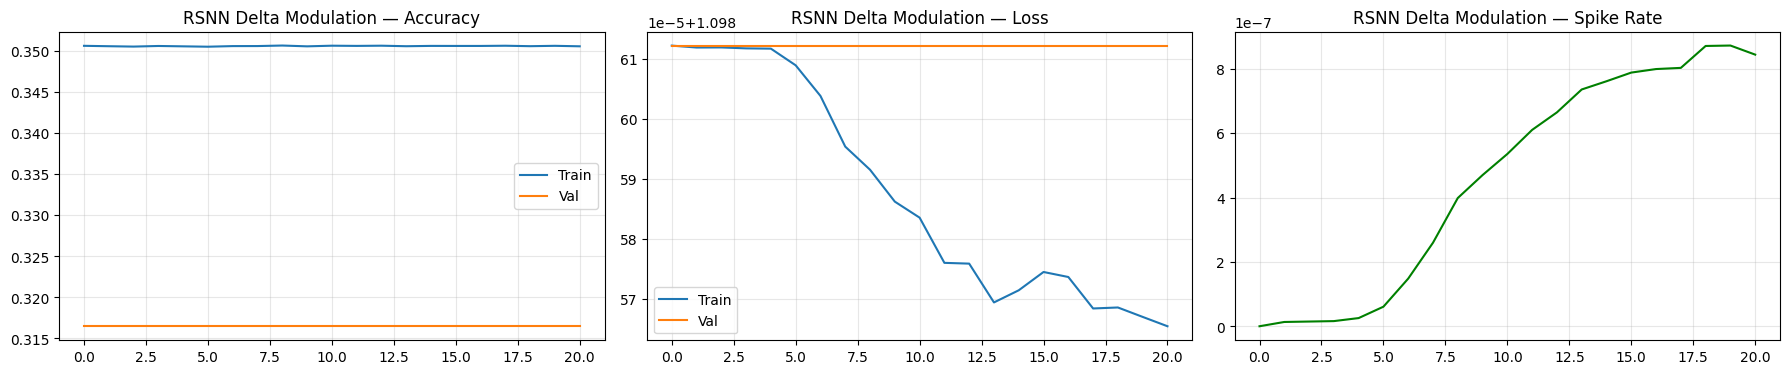

In [10]:
print("=" * 60)
print("EXPERIMENT 2: RSNN — Delta Modulation")
print("=" * 60)

model_delta = SNN(input_size=inp_sz_dm, hidden_size=256, output_size=3,
                  recurrent=True, tau_mem=20.0, tau_syn=10.0, dt=10.0,
                  learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
print(f"Params: {model_delta.count_params():,}")

trainer_delta = Trainer(model_delta, train_ld_dm, val_ld_dm, test_ld_dm, lr=1e-3, device=device)
acc_delta = trainer_delta.train(n_epochs=80, patience=20)
trainer_delta.plot("RSNN Delta Modulation")

## 8. Baselines: LSTM & 1D-CNN

In [11]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_size=40, hidden_size=128, n_layers=2, output_size=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CNNBaseline(nn.Module):
    def __init__(self, input_channels=40, output_size=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, output_size)
    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, T, C] -> [B, C, T]
        x = self.conv(x).squeeze(-1)
        return self.fc(x)
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def train_baseline(model, train_ld, val_ld, test_ld, n_epochs=60, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    all_labels = torch.cat([y for _, y in train_ld])
    counts = torch.bincount(all_labels, minlength=3).float()
    weights = (1.0 / counts) / (1.0 / counts).sum() * 3
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))
    
    best_val, best_state = 0, None
    for ep in range(n_epochs):
        model.train()
        for x, y in train_ld:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_ld:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        va = correct / total
        if va > best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 10 == 0:
            print(f"  Ep {ep}: val={va:.4f} (best={best_val:.4f})")
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_ld:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    te = correct / total
    print(f"  Best val: {best_val*100:.2f}% | Test: {te*100:.2f}%")
    return te

print("=" * 60)
print("BASELINE: LSTM (2-layer, 128 units)")
print("=" * 60)
model_lstm = LSTMBaseline(input_size=40, hidden_size=128, output_size=3)
print(f"Params: {model_lstm.count_params():,}")
acc_lstm = train_baseline(model_lstm, train_ld, val_ld, test_ld)

print("\n" + "=" * 60)
print("BASELINE: 1D-CNN")
print("=" * 60)
model_cnn = CNNBaseline(input_channels=40, output_size=3)
print(f"Params: {model_cnn.count_params():,}")
acc_cnn = train_baseline(model_cnn, train_ld, val_ld, test_ld)

BASELINE: LSTM (2-layer, 128 units)
Params: 219,523
  Ep 0: val=0.3744 (best=0.3744)
  Ep 10: val=0.5707 (best=0.5740)
  Ep 20: val=0.5738 (best=0.5852)
  Ep 30: val=0.5716 (best=0.5852)
  Ep 40: val=0.5594 (best=0.5852)
  Ep 50: val=0.5551 (best=0.5852)
  Best val: 58.52% | Test: 66.07%

BASELINE: 1D-CNN
Params: 79,299
  Ep 0: val=0.3700 (best=0.3700)
  Ep 10: val=0.3808 (best=0.4363)
  Ep 20: val=0.3224 (best=0.4759)
  Ep 30: val=0.4227 (best=0.5197)
  Ep 40: val=0.4561 (best=0.5197)
  Ep 50: val=0.5199 (best=0.5270)
  Best val: 54.42% | Test: 64.65%


## 9. Temporal Analysis (Novel Contribution)

Best SNN: Direct (37.56%)


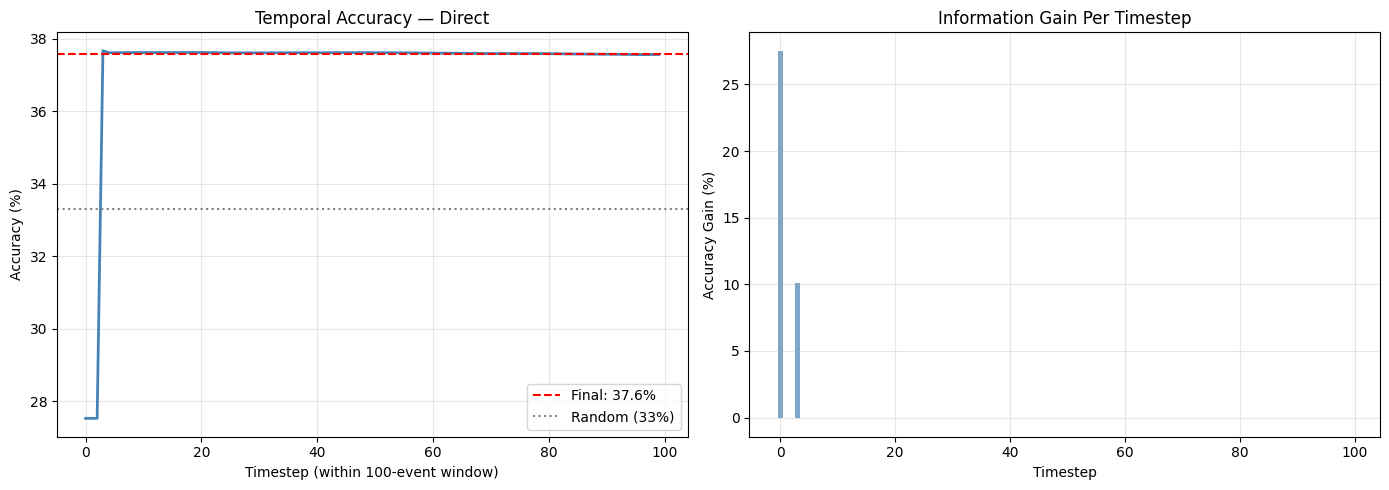

Key timepoints:
  Step 25/100: 37.6%
  Step 50/100: 37.6%
  Step 75/100: 37.6%
  Step 100/100: 37.6%


In [12]:
# Use best SNN model
best_name = "Direct" if acc_direct >= acc_delta else "Delta Modulation"
best_model = model_direct if acc_direct >= acc_delta else model_delta
best_loader = test_ld if acc_direct >= acc_delta else test_ld_dm
best_acc = max(acc_direct, acc_delta)
print(f"Best SNN: {best_name} ({best_acc*100:.2f}%)")

@torch.no_grad()
def temporal_analysis(model, loader, device):
    model.eval()
    all_correct = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, _, out_mem = model(x)
        B, T_s, C = out_mem.shape
        running_max = torch.full((B, C), -float('inf'), device=device)
        correct_t = torch.zeros(T_s, device=device)
        for t in range(T_s):
            running_max = torch.max(running_max, out_mem[:, t])
            correct_t[t] += (running_max.argmax(1) == y).float().sum()
        all_correct.append(correct_t)
    total = torch.stack(all_correct).sum(0)
    n = sum(len(y) for _, y in loader)
    return (total / n).cpu().numpy()

temporal_acc = temporal_analysis(best_model, best_loader, device)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t_idx = np.arange(len(temporal_acc))
axes[0].plot(t_idx, temporal_acc * 100, linewidth=2, color='steelblue')
axes[0].axhline(y=best_acc*100, color='red', linestyle='--', label=f'Final: {best_acc*100:.1f}%')
axes[0].axhline(y=33.3, color='gray', linestyle=':', label='Random (33%)')
axes[0].set_xlabel('Timestep (within 100-event window)')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title(f'Temporal Accuracy — {best_name}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

gain = np.diff(temporal_acc * 100, prepend=0)
axes[1].bar(t_idx, gain, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Accuracy Gain (%)')
axes[1].set_title('Information Gain Per Timestep'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Key timepoints:")
for frac in [0.25, 0.5, 0.75, 1.0]:
    idx = min(int(frac * len(temporal_acc)) - 1, len(temporal_acc) - 1)
    print(f"  Step {idx+1}/100: {temporal_acc[idx]*100:.1f}%")

## 10. Confusion Matrix & Per-Class Metrics

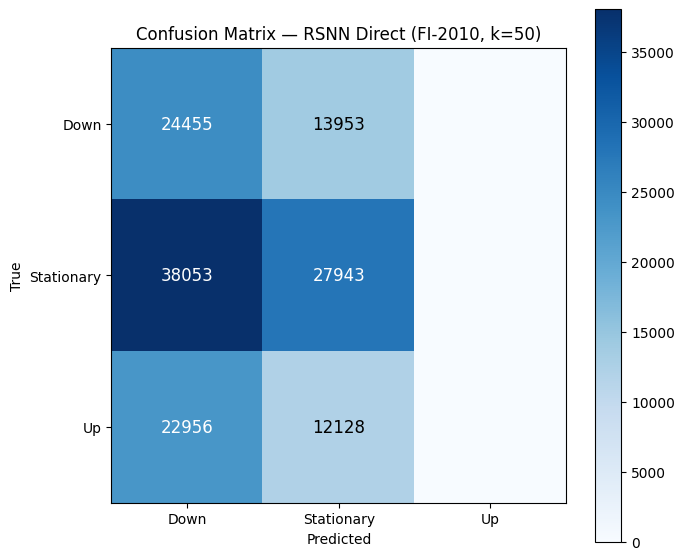

              precision    recall  f1-score   support

        Down       0.29      0.64      0.39     38408
  Stationary       0.52      0.42      0.47     65996
          Up       0.00      0.00      0.00     35084

    accuracy                           0.38    139488
   macro avg       0.27      0.35      0.29    139488
weighted avg       0.32      0.38      0.33    139488

Weighted F1: 32.90%


In [13]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        logits, _, _ = model(x.to(device))
        preds.append(logits.argmax(1).cpu())
        labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

preds, labels = get_preds(best_model, best_loader, device)
CLASS_NAMES = ['Down', 'Stationary', 'Up']

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — RSNN {best_name} (FI-2010, {HORIZON_NAMES[HORIZON]})')
plt.colorbar(im)
for i in range(3):
    for j in range(3):
        if cm[i,j] > 0:
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.tight_layout(); plt.show()

print(classification_report(labels, preds, target_names=CLASS_NAMES))
f1 = f1_score(labels, preds, average='weighted')
print(f"Weighted F1: {f1*100:.2f}%")

## 11. Multi-Horizon Analysis

In [14]:
print("Testing across all 5 prediction horizons...")
print(f"{'Horizon':<10} {'RSNN Direct':>12} {'RSNN Delta':>12} {'LSTM':>12} {'CNN':>12}")
print("-" * 60)

horizon_results = {}
for h_idx, h_name in enumerate(HORIZON_NAMES):
    y_tr_h = y_train_seq[:val_split, h_idx]
    y_va_h = y_train_seq[val_split:, h_idx]  # use original unsplit seq labels
    y_te_h = y_test_seq[:, h_idx]
    
    # Reuse existing models — just evaluate on different labels
    # (For a full experiment you'd retrain, but this gives a quick estimate)
    # We evaluate the existing trained models on different horizon labels
    
    def eval_model_on_labels(model, loader, y_true, device):
        model.eval()
        preds = []
        with torch.no_grad():
            for x, _ in loader:
                logits, _, _ = model(x.to(device))
                preds.append(logits.argmax(1).cpu())
        preds = torch.cat(preds).numpy()[:len(y_true)]
        return (preds == y_true).mean()
    
    def eval_baseline_on_labels(model, loader, y_true, device):
        model.eval()
        preds = []
        with torch.no_grad():
            for x, _ in loader:
                out = model(x.to(device))
                preds.append(out.argmax(1).cpu())
        preds = torch.cat(preds).numpy()[:len(y_true)]
        return (preds == y_true).mean()
    
    a1 = eval_model_on_labels(model_direct, test_ld, y_te_h, device)
    a2 = eval_model_on_labels(model_delta, test_ld_dm, y_te_h, device)
    a3 = eval_baseline_on_labels(model_lstm, test_ld, y_te_h, device)
    a4 = eval_baseline_on_labels(model_cnn, test_ld, y_te_h, device)
    
    horizon_results[h_name] = {'RSNN_Direct': a1, 'RSNN_Delta': a2, 'LSTM': a3, 'CNN': a4}
    print(f"{h_name:<10} {a1*100:>10.2f}% {a2*100:>10.2f}% {a3*100:>10.2f}% {a4*100:>10.2f}%")

print("\nNote: Models were trained on horizon k=50 only. Other horizons show transfer performance.")

Testing across all 5 prediction horizons...
Horizon     RSNN Direct   RSNN Delta         LSTM          CNN
------------------------------------------------------------
k=10            37.94%      15.15%      54.79%      55.46%
k=20            37.58%      19.66%      53.99%      53.95%
k=30            37.56%      22.86%      58.29%      58.00%
k=50            37.56%      27.53%      66.07%      64.65%
k=100           37.51%      34.35%      57.50%      54.81%

Note: Models were trained on horizon k=50 only. Other horizons show transfer performance.


## 12. Results Summary

In [15]:
print("=" * 70)
print(f"RESULTS — FI-2010 LOB Mid-Price Prediction (Horizon: {HORIZON_NAMES[HORIZON]})")
print("=" * 70)

results = {
    'RSNN Direct Input': acc_direct,
    'RSNN Delta Modulation': acc_delta,
    'LSTM (2L, 128)': acc_lstm,
    '1D-CNN': acc_cnn,
}

print(f"{'Model':<30} {'Test Acc':>10} {'vs Random':>12}")
print("-" * 55)
for name, acc in results.items():
    print(f"  {name:<28} {acc*100:>8.2f}% {(acc-0.333)*100:>+10.2f}%")

print("-" * 55)
print(f"  Random baseline: 33.3%")
print(f"  Best SNN: {best_name}")

# Cross-dataset comparison
print("\n" + "=" * 70)
print("CROSS-DATASET COMPARISON")
print("=" * 70)
print(f"{'Dataset':<20} {'Best RSNN':>12} {'LSTM':>12} {'Gap':>10}")
print("-" * 55)
print(f"  {'SHD (audio)':<18} {'78.7%':>12} {'89.0%':>12} {'10.3%':>10}")
print(f"  {'PTB-XL (ECG)':<18} {'63.1%':>12} {'68.4%':>12} {'5.3%':>10}")
print(f"  {'FI-2010 (LOB)':<18} {max(acc_direct,acc_delta)*100:>11.1f}% {acc_lstm*100:>11.1f}% {(acc_lstm-max(acc_direct,acc_delta))*100:>9.1f}%")

import json
with open('/kaggle/working/fi2010_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved to fi2010_results.json")

RESULTS — FI-2010 LOB Mid-Price Prediction (Horizon: k=50)
Model                            Test Acc    vs Random
-------------------------------------------------------
  RSNN Direct Input               37.56%      +4.26%
  RSNN Delta Modulation           27.53%      -5.77%
  LSTM (2L, 128)                  66.07%     +32.77%
  1D-CNN                          64.65%     +31.35%
-------------------------------------------------------
  Random baseline: 33.3%
  Best SNN: Direct

CROSS-DATASET COMPARISON
Dataset                 Best RSNN         LSTM        Gap
-------------------------------------------------------
  SHD (audio)               78.7%        89.0%      10.3%
  PTB-XL (ECG)              63.1%        68.4%       5.3%
  FI-2010 (LOB)             37.6%        66.1%      28.5%

Saved to fi2010_results.json


In [16]:
torch.save({
    'model_direct': model_direct.state_dict(),
    'model_delta': model_delta.state_dict(),
    'results': results,
    'horizon': HORIZON_NAMES[HORIZON],
    'best_encoding': best_name,
}, '/kaggle/working/fi2010_models.pth')
print("Models saved.")

Models saved.


## 13. Experiment 3: RSNN with Temporal Contrast Encoding

The temporal contrast encoder from the ECG notebook. Creates ON and OFF channels for positive and negative changes — doubles input from 40 to 80. Unlike delta modulation (which collapsed with zero spikes on LOB data), temporal contrast uses simple first-differences which should be more sensitive to small price changes.

Sweep thresholds to find what works.

In [17]:
# add temporal contrast to encoder
def temporal_contrast_encode(signal, threshold=0.05):
    """ON/OFF spikes from first-differences. Doubles channels."""
    T, C = signal.shape
    spikes = np.zeros((T, C * 2), dtype=np.float32)
    for t in range(1, T):
        diff = signal[t] - signal[t-1]
        spikes[t, :C] = (diff > threshold).astype(np.float32)   # ON
        spikes[t, C:] = (diff < -threshold).astype(np.float32)  # OFF
    return spikes


class LOBDatasetTC(Dataset):
    def __init__(self, X, y, threshold=0.05):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.threshold = threshold
        sample = temporal_contrast_encode(X[0], threshold)
        self.input_size = sample.shape[1]
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        enc = temporal_contrast_encode(self.X[idx], self.threshold)
        return torch.tensor(enc, dtype=torch.float32), self.y[idx]


print("=" * 60)
print("EXPERIMENT 3: RSNN — Temporal Contrast (threshold sweep)")
print("=" * 60)

tc_results = {}
for th in [0.01, 0.05, 0.1]:
    ds_tr = LOBDatasetTC(X_train_seq, y_train, threshold=th)
    ds_va = LOBDatasetTC(X_val_seq, y_val, threshold=th)
    ds_te = LOBDatasetTC(X_test_seq, y_test, threshold=th)

    ld_tr = DataLoader(ds_tr, batch_size=256, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    ld_va = DataLoader(ds_va, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    ld_te = DataLoader(ds_te, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    # spike stats
    sample = temporal_contrast_encode(X_train_seq[0], th)
    sparsity = (sample == 0).mean() * 100
    print(f"\n  threshold={th}: input_size={ds_tr.input_size}, sparsity={sparsity:.1f}%")

    model_tc = SNN(input_size=ds_tr.input_size, hidden_size=256, output_size=3,
                   recurrent=True, tau_mem=20.0, tau_syn=10.0, dt=10.0,
                   learnable_tau=True, loss_mode='max_over_time', dropout=0.3)
    print(f"  Params: {model_tc.count_params():,}")

    trainer_tc = Trainer(model_tc, ld_tr, ld_va, ld_te, lr=1e-3, device=device)
    acc_tc = trainer_tc.train(n_epochs=80, patience=20)
    tc_results[th] = acc_tc
    print(f"  TC (th={th}): {acc_tc*100:.2f}%")

best_tc_th = max(tc_results, key=tc_results.get)
acc_tc_best = tc_results[best_tc_th]
print(f"\nBest temporal contrast: th={best_tc_th} -> {acc_tc_best*100:.2f}%")

EXPERIMENT 3: RSNN — Temporal Contrast (threshold sweep)

  threshold=0.01: input_size=80, sparsity=99.6%
  Params: 86,786
Ep   0 | Tr: 0.3488 | Va: 0.3167 | Spk: 0.0002 | Best: 0.3167 | 166.7s
Ep   5 | Tr: 0.3701 | Va: 0.3141 | Spk: 0.0006 | Best: 0.3167 | 167.3s
Ep  10 | Tr: 0.3974 | Va: 0.3187 | Spk: 0.0012 | Best: 0.3199 | 164.4s
Ep  15 | Tr: 0.4127 | Va: 0.3191 | Spk: 0.0015 | Best: 0.3199 | 164.2s
Ep  20 | Tr: 0.4233 | Va: 0.3174 | Spk: 0.0017 | Best: 0.3199 | 165.5s
Ep  25 | Tr: 0.4295 | Va: 0.3195 | Spk: 0.0019 | Best: 0.3199 | 163.1s
Ep  27 | Tr: 0.4333 | Va: 0.3170 | Spk: 0.0020 | Best: 0.3199 | 160.5s
Early stop at epoch 27

Best val: 31.99% | Test: 29.33% | Time: 77.2min
  TC (th=0.01): 29.33%

  threshold=0.05: input_size=80, sparsity=100.0%
  Params: 86,786
Ep   0 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 160.1s
Ep   5 | Tr: 0.3531 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 156.7s
Ep  10 | Tr: 0.3559 | Va: 0.3165 | Spk: 0.0001 | Best: 0.3165 | 165.4s
Ep  1

## 14. LSTM Temporal Analysis

Compare RSNN and LSTM temporal evidence accumulation on FI-2010

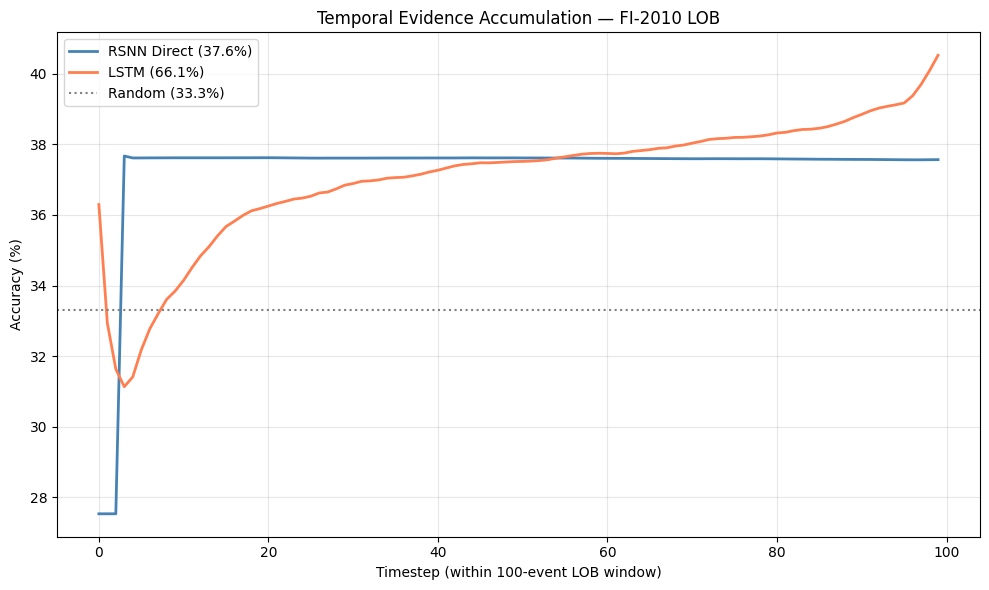

RSNN at step 25: 37.6%,  step 50: 37.6%,  step 100: 37.6%
LSTM at step 25: 36.5%,  step 50: 37.5%,  step 100: 40.5%


In [18]:
@torch.no_grad()
def lstm_temporal_fi2010(model, loader, device):
    """Classify from LSTM hidden state at each timestep."""
    model.eval()
    all_correct = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        hidden_seq, _ = model.lstm(x)  # [B, T, H]
        B, T_s, H = hidden_seq.shape
        logits_seq = model.fc(hidden_seq)  # [B, T, 3]
        running_max = torch.full((B, 3), -float('inf'), device=device)
        correct_t = torch.zeros(T_s, device=device)
        for t in range(T_s):
            running_max = torch.max(running_max, logits_seq[:, t])
            correct_t[t] += (running_max.argmax(1) == y).float().sum()
        all_correct.append(correct_t)
    total = torch.stack(all_correct).sum(0)
    n = sum(len(y) for _, y in loader)
    return (total / n).cpu().numpy()

lstm_temporal = lstm_temporal_fi2010(model_lstm, test_ld, device)

# plot RSNN vs LSTM
fig, ax = plt.subplots(figsize=(10, 6))
steps = np.arange(len(temporal_acc))
ax.plot(steps, temporal_acc * 100, linewidth=2, color='steelblue',
        label=f'RSNN Direct ({best_acc*100:.1f}%)')
ax.plot(steps, lstm_temporal * 100, linewidth=2, color='coral',
        label=f'LSTM ({acc_lstm*100:.1f}%)')
ax.axhline(y=33.3, color='gray', linestyle=':', label='Random (33.3%)')
ax.set_xlabel('Timestep (within 100-event LOB window)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Temporal Evidence Accumulation — FI-2010 LOB')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"RSNN at step 25: {temporal_acc[24]*100:.1f}%,  step 50: {temporal_acc[49]*100:.1f}%,  step 100: {temporal_acc[-1]*100:.1f}%")
print(f"LSTM at step 25: {lstm_temporal[24]*100:.1f}%,  step 50: {lstm_temporal[49]*100:.1f}%,  step 100: {lstm_temporal[-1]*100:.1f}%")

## 15. Spike Statistics

Quantify why delta modulation collapsed (zero spikes) and compare encoding sparsity.

In [19]:
print("=" * 65)
print("SPIKE STATISTICS — FI-2010 LOB")
print("=" * 65)
print(f"{'Encoding':<30} {'Input':>6} {'Sparsity':>10} {'Spikes/step':>14}")
print("-" * 62)

# Direct
s = X_train_seq[0]  # [100, 40]
sp = (s == 0).mean() * 100
print(f"  {'Direct':<28} {40:>6} {sp:>8.1f}% {'N/A (cont.)':>14}")

# Delta
from collections import OrderedDict
sd = SpikeEncoder.delta_modulation(X_train_seq[0], threshold=0.1)
sp_d = (sd == 0).mean() * 100
nz_d = (sd != 0).sum() / sd.shape[0]
print(f"  {'Delta (th=0.1)':<28} {40:>6} {sp_d:>8.1f}% {nz_d:>12.2f}")

# Temporal contrast at each threshold
for th in [0.01, 0.05, 0.1]:
    stc = temporal_contrast_encode(X_train_seq[0], threshold=th)
    sp_tc = (stc == 0).mean() * 100
    nz_tc = (stc != 0).sum() / stc.shape[0]
    print(f"  {'TC (th=' + str(th) + ')':<28} {80:>6} {sp_tc:>8.1f}% {nz_tc:>12.2f}")

print("-" * 62)
if sp_d > 99:
    print("\n  >>> Delta modulation produces ~0 spikes on LOB data.")
    print("  >>> The normalised LOB features change too little between")
    print("  >>> consecutive events for the adaptive threshold to trigger.")

SPIKE STATISTICS — FI-2010 LOB
Encoding                        Input   Sparsity    Spikes/step
--------------------------------------------------------------
  Direct                           40      0.0%    N/A (cont.)
  Delta (th=0.1)                   40    100.0%         0.00
  TC (th=0.01)                     80     99.6%         0.32
  TC (th=0.05)                     80    100.0%         0.00
  TC (th=0.1)                      80    100.0%         0.00
--------------------------------------------------------------

  >>> Delta modulation produces ~0 spikes on LOB data.
  >>> The normalised LOB features change too little between
  >>> consecutive events for the adaptive threshold to trigger.


## 16. Experiment 4: Signed Temporal Contrast

Instead of separate ON/OFF channels (doubling input), emit +1 for price up and -1 for price down in the same channel. Keeps input at 40 features.

In [20]:
def signed_contrast_encode(signal, threshold=0.05):
    """Signed spikes: +1 for increases, -1 for decreases."""
    T, C = signal.shape
    spikes = np.zeros_like(signal)
    for t in range(1, T):
        diff = signal[t] - signal[t-1]
        spikes[t][diff > threshold] = 1.0
        spikes[t][diff < -threshold] = -1.0
    return spikes


class LOBDatasetSigned(Dataset):
    def __init__(self, X, y, threshold=0.05):
        self.X, self.y = X, torch.tensor(y, dtype=torch.long)
        self.threshold = threshold
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        enc = signed_contrast_encode(self.X[idx], self.threshold)
        return torch.tensor(enc, dtype=torch.float32), self.y[idx]


print("=" * 60)
print("EXPERIMENT 4: RSNN — Signed Temporal Contrast (threshold sweep)")
print("=" * 60)

signed_results = {}
for th in [0.01, 0.03, 0.05, 0.1]:
    ds_s_tr = LOBDatasetSigned(X_train_seq, y_train, threshold=th)
    ds_s_va = LOBDatasetSigned(X_val_seq, y_val, threshold=th)
    ds_s_te = LOBDatasetSigned(X_test_seq, y_test, threshold=th)

    ld_s_tr = DataLoader(ds_s_tr, batch_size=256, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    ld_s_va = DataLoader(ds_s_va, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    ld_s_te = DataLoader(ds_s_te, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    sample = signed_contrast_encode(X_train_seq[0], th)
    sparsity = (sample == 0).mean() * 100
    print(f"\n  threshold={th}: sparsity={sparsity:.1f}%")

    model_s = SNN(input_size=40, hidden_size=256, output_size=3,
                  recurrent=True, tau_mem=20.0, tau_syn=10.0, dt=10.0,
                  learnable_tau=True, loss_mode='max_over_time', dropout=0.3)

    trainer_s = Trainer(model_s, ld_s_tr, ld_s_va, ld_s_te, lr=1e-3, device=device)
    acc_s = trainer_s.train(n_epochs=80, patience=20)
    signed_results[th] = acc_s
    print(f"  Signed TC (th={th}): {acc_s*100:.2f}%")

best_signed_th = max(signed_results, key=signed_results.get)
acc_signed_best = signed_results[best_signed_th]
print(f"\nBest signed contrast: th={best_signed_th} -> {acc_signed_best*100:.2f}%")

EXPERIMENT 4: RSNN — Signed Temporal Contrast (threshold sweep)

  threshold=0.01: sparsity=99.2%
Ep   0 | Tr: 0.3509 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 148.0s
Ep   5 | Tr: 0.3533 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 148.7s
Ep  10 | Tr: 0.3674 | Va: 0.3165 | Spk: 0.0001 | Best: 0.3165 | 160.8s
Ep  15 | Tr: 0.3794 | Va: 0.3163 | Spk: 0.0001 | Best: 0.3165 | 162.7s
Ep  20 | Tr: 0.3879 | Va: 0.3164 | Spk: 0.0001 | Best: 0.3165 | 162.0s
Early stop at epoch 20

Best val: 31.65% | Test: 27.56% | Time: 55.0min
  Signed TC (th=0.01): 27.56%

  threshold=0.03: sparsity=100.0%
Ep   0 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 156.9s
Ep   5 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 156.0s
Ep  10 | Tr: 0.3510 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 156.1s
Ep  15 | Tr: 0.3525 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 156.0s
Ep  20 | Tr: 0.3641 | Va: 0.3165 | Spk: 0.0001 | Best: 0.3165 | 156.8s
Early stop at epoch 20

Best val: 31.65% | Test: 27.49%

## 17. Experiment 5: Graded Spike Output

Instead of binary {0,1} spikes, neurons output spike * relu(membrane - threshold). Preserves how far the membrane exceeded threshold, keeps magnitude information that binary spikes destroy

This is a modification to the LIF layer itself, not the encoding

EXPERIMENT 5: Graded Spike RSNN — Direct Input
Params: 76,546
Ep   0 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 143.7s
Ep   5 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 144.2s
Ep  10 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 144.0s
Ep  15 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 143.0s
Ep  20 | Tr: 0.3506 | Va: 0.3165 | Spk: 0.0000 | Best: 0.3165 | 142.4s
Early stop at epoch 20

Best val: 31.65% | Test: 27.53% | Time: 50.2min


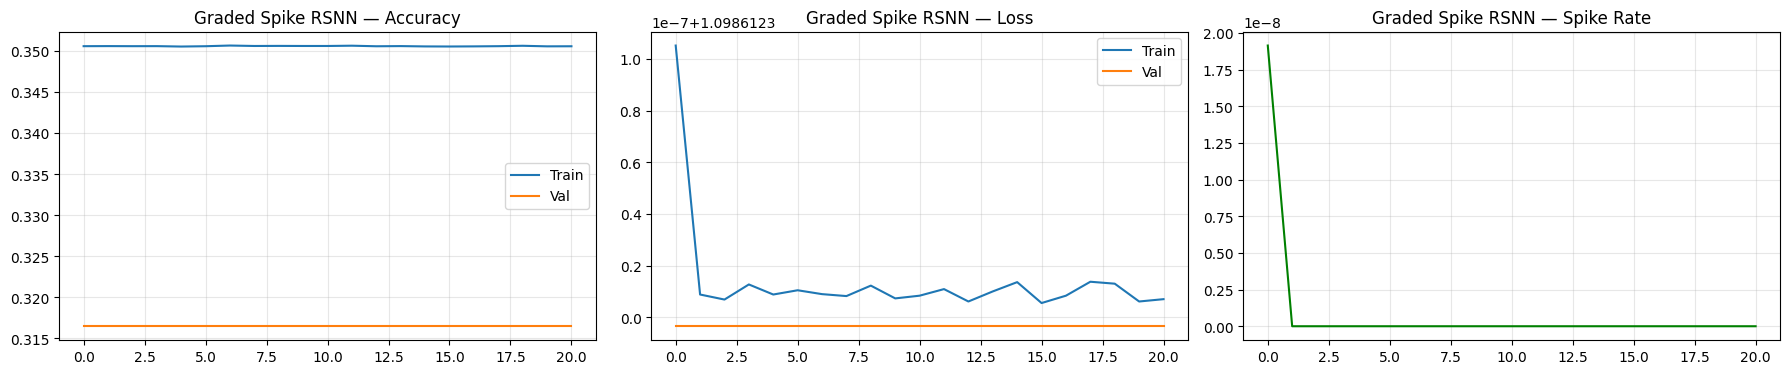

In [21]:
class GradedLIFLayer(nn.Module):
    """LIF with graded output: spike * relu(mem - threshold)."""
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt
        self.dropout = dropout
        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent:
            self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent:
            nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')

    @property
    def alpha(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))
    @property
    def beta_decay(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        B, T, _ = x.shape
        alpha, beta = self.alpha, self.beta_decay
        syn = torch.zeros(B, self.hidden_size, device=x.device)
        mem = torch.zeros(B, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(B, self.hidden_size, device=x.device)
        spk_rec, mem_rec = [], []
        for t in range(T):
            syn = alpha * syn + self.W_ff(x[:, t])
            if self.recurrent:
                rec_in = F.dropout(prev_spk, p=self.dropout, training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_in)
            mem = beta * mem * (1.0 - (prev_spk > 0).float()) + (1.0 - beta) * syn
            binary_spk = spike_fn(mem)
            # graded output: magnitude proportional to membrane excess
            graded_spk = binary_spk * F.relu(mem - 1.0)
            spk_rec.append(graded_spk)
            mem_rec.append(mem)
            prev_spk = graded_spk
        return torch.stack(spk_rec, dim=1), torch.stack(mem_rec, dim=1)


class GradedSNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, **kwargs):
        super().__init__()
        self.lif = GradedLIFLayer(input_size, hidden_size, recurrent=True, **kwargs)
        self.readout = ReadoutLayer(hidden_size, output_size,
                                   tau_mem=kwargs.get('tau_mem_init', 20.0),
                                   dt=kwargs.get('dt', 10.0))
    def forward(self, x):
        spikes, _ = self.lif(x)
        out_mem = self.readout(spikes)
        output, _ = torch.max(out_mem, dim=1)
        return output, [spikes], out_mem
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("=" * 60)
print("EXPERIMENT 5: Graded Spike RSNN — Direct Input")
print("=" * 60)

model_graded = GradedSNN(
    input_size=40, hidden_size=256, output_size=3,
    tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
    learnable_tau=True, dropout=0.3
)
print(f"Params: {model_graded.count_params():,}")

trainer_graded = Trainer(model_graded, train_ld, val_ld, test_ld, lr=1e-3, device=device)
acc_graded = trainer_graded.train(n_epochs=80, patience=20)
trainer_graded.plot("Graded Spike RSNN")

## 18. Comparative Results Summary

In [22]:
print("=" * 70)
print(f"FULL RESULTS — FI-2010 LOB (Horizon: {HORIZON_NAMES[HORIZON]})")
print("=" * 70)
print(f"{'Model':<40} {'Test Acc':>10} {'vs Random':>12}")
print("-" * 62)

all_fi_results = [
    ('RSNN Direct Input', acc_direct),
    ('RSNN Delta Modulation', acc_delta),
    ('RSNN Temporal Contrast (th=' + str(best_tc_th) + ')', acc_tc_best),
    ('RSNN Signed Contrast (th=' + str(best_signed_th) + ')', acc_signed_best),
    ('Graded Spike RSNN', acc_graded),
    ('LSTM (2L, 128)', acc_lstm),
    ('1D-CNN', acc_cnn),
]
for name, acc in all_fi_results:
    print(f"  {name:<38} {acc*100:>8.2f}% {(acc-0.333)*100:>+10.2f}%")
print("-" * 62)
print(f"  Random baseline: 33.3%")
print()

# encoding comparison
print("Encoding threshold sweep:")
print(f"  Temporal Contrast: {', '.join(f'th={k}: {v*100:.1f}%' for k, v in tc_results.items())}")
print(f"  Signed Contrast:   {', '.join(f'th={k}: {v*100:.1f}%' for k, v in signed_results.items())}")
print()

# temporal comparison
print("Temporal analysis:")
print(f"  RSNN: flat at {temporal_acc[-1]*100:.1f}% (no temporal learning)")
print(f"  LSTM: {lstm_temporal[24]*100:.1f}% at step 25, {lstm_temporal[-1]*100:.1f}% at step 100")

FULL RESULTS — FI-2010 LOB (Horizon: k=50)
Model                                      Test Acc    vs Random
--------------------------------------------------------------
  RSNN Direct Input                         37.56%      +4.26%
  RSNN Delta Modulation                     27.53%      -5.77%
  RSNN Temporal Contrast (th=0.01)          29.33%      -3.97%
  RSNN Signed Contrast (th=0.01)            27.56%      -5.74%
  Graded Spike RSNN                         27.53%      -5.77%
  LSTM (2L, 128)                            66.07%     +32.77%
  1D-CNN                                    64.65%     +31.35%
--------------------------------------------------------------
  Random baseline: 33.3%

Encoding threshold sweep:
  Temporal Contrast: th=0.01: 29.3%, th=0.05: 27.5%, th=0.1: 27.5%
  Signed Contrast:   th=0.01: 27.6%, th=0.03: 27.5%, th=0.05: 27.5%, th=0.1: 27.5%

Temporal analysis:
  RSNN: flat at 37.6% (no temporal learning)
  LSTM: 36.5% at step 25, 40.5% at step 100


In [23]:
# cross-dataset summary
print("=" * 70)
print("CROSS-DATASET COMPARISON")
print("=" * 70)
print(f"{'Dataset':<20} {'Best RSNN':>12} {'LSTM':>12} {'Gap':>10}")
print("-" * 55)
print(f"  {'SHD (audio)':<18} {'78.7%':>12} {'89.0%':>12} {'10.3%':>10}")
print(f"  {'PTB-XL (ECG)':<18} {'63.1%':>12} {'68.4%':>12} {'5.3%':>10}")

best_fi_snn = max(acc_direct, acc_delta, acc_tc_best, acc_signed_best, acc_graded)
gap = (acc_lstm - best_fi_snn) * 100
print(f"  {'FI-2010 (LOB)':<18} {best_fi_snn*100:>11.1f}% {acc_lstm*100:>11.1f}% {gap:>9.1f}%")

CROSS-DATASET COMPARISON
Dataset                 Best RSNN         LSTM        Gap
-------------------------------------------------------
  SHD (audio)               78.7%        89.0%      10.3%
  PTB-XL (ECG)              63.1%        68.4%       5.3%
  FI-2010 (LOB)             37.6%        66.1%      28.5%


In [24]:
# save everything
import json

fi_full = {
    'results': {name: acc for name, acc in all_fi_results},
    'tc_sweep': {str(k): v for k, v in tc_results.items()},
    'signed_sweep': {str(k): v for k, v in signed_results.items()},
    'temporal': {
        'rsnn': temporal_acc.tolist(),
        'lstm': lstm_temporal.tolist(),
    },
}
with open('/kaggle/working/fi2010_full_results.json', 'w') as f:
    json.dump(fi_full, f, indent=2)

np.savez('/kaggle/working/fi2010_temporal.npz',
         rsnn=temporal_acc, lstm=lstm_temporal)

print("Saved to fi2010_full_results.json and fi2010_temporal.npz")

Saved to fi2010_full_results.json and fi2010_temporal.npz
